# thalamus: spindle3 for 多次运行

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
import defaultParameters as dp
#params = dp.loadDefaultParams(0)
#params["scale2"] = 0.004
#params 

In [ ]:
n_runs = 10
#params_list = np.linspace(0,0.009,2)
params_list = np.linspace(0,0.009,10)
for param in params_list:
    for seed in range(1, n_runs):
        params = dp.loadDefaultParams(seed)
        params["scale2"] = param 
        t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        
        # 只保存 raw 信号（用 .npy 格式，非常快）
        save_path = f"data/raw_data/scale2_{param}_seed_{seed}.npy"
        np.save(save_path, {"t": t, "V_e": V_e, "V_i": V_i, "Q_e": Q_e, "Q_i": Q_i, "V_t": V_t, "V_r": V_r, "Q_t": Q_t, "Q_r": Q_r})

In [4]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
from scipy.signal import butter, filtfilt
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal

# ========== 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数
SW = {"low_freq": None, "high_freq": 3.0}

def get_phase(signal, filter_args, pad=None):
    """提取信号的瞬时相位"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase

# ========== 批量处理 ==========
all_spindles = []
file_list = glob.glob("data/raw_data/*.npy")

for file_path in file_list:
    # 解析文件名，提取参数和 seed
    file_path = file_path.replace("\\", "/")
    print(file_path)
    filename = file_path.split("/")[-1]
    parts = filename.replace(".npy", "").split("_")
    param = float(parts[1])   # scale2_{param}
    seed = int(parts[3])      # seed_{seed}
    
    print(f"Processing: param={param}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界（秒）
    t_min = remove_edges_samples 
    t_max = t[-1] - remove_edges_samples 
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_t_mid = V_t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame(
        {"ALN": V_e_mid, "TCR": V_t_mid},
        index=t_mid/10000,
    )
    results_df.index.name = "time"
    
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位（pad=0，因为边界已经被手动切掉）
    aln_so_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    slow_phase = aln_so_phase.data.values
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    if sp_fast is not None:
        df = sp_fast.summary()
        for _, row in df.iterrows():
            start_time = row["Start"] * 10000
            peak_time = row["Peak"]* 10000
            end_time = row["End"]* 10000
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_time <= t_max and 
                    t_min <= end_time <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_time))
            peak_idx = np.argmin(np.abs(t_mid - peak_time))
            
            all_spindles.append({
                "param": param,
                "seed": seed,
                "type": "fast",
                "start": start_time/10000,
                "peak_time": peak_time/10000,
                "end": end_time/10000,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": slow_phase[start_idx],
                "phase_at_peak": slow_phase[peak_idx],
            })
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    if sp_slow is not None:
        df = sp_slow.summary()
        for _, row in df.iterrows():
            start_time = row["Start"] * 10000
            peak_time = row["Peak"]* 10000
            end_time = row["End"]* 10000
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_time <= t_max and 
                    t_min <= end_time <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_time))
            peak_idx = np.argmin(np.abs(t_mid - peak_time))
            
            all_spindles.append({
                "param": param,
                "seed": seed,
                "type": "slow",
                "start": start_time/10000,
                "peak_time": peak_time/10000,
                "end": end_time/10000,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": slow_phase[start_idx],
                "phase_at_peak": slow_phase[peak_idx],
            })
    
    print(f"  完成：快纺锤波={len(sp_fast.summary()) if sp_fast else 0}, 慢纺锤波={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/spindles_all.csv", index=False)
print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(result_df.head())

data/raw_data/scale2_0.009_seed_1.npy
Processing: param=0.009, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBacke

  完成：快纺锤波=1, 慢纺锤波=2
data/raw_data/scale2_0.0_seed_1.npy
Processing: param=0.0, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快纺锤波=1, 慢纺锤波=2

总共检测到 2 个纺锤波
   param  seed  type   start  peak_time     end  duration  frequency  \
0  0.009     1  slow  2.5694     2.9041  3.3362    0.7668  10.366004   
1  0.000     1  slow  2.5694     2.9041  3.3362    0.7668  10.366004   

   amplitude  phase_at_start  phase_at_peak  
0    3.82333        -1.93998      -1.440542  
1    3.82333        -1.93998      -1.440542  


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


In [5]:
sgahkgl

NameError: name 'sgahkgl' is not defined

In [ ]:
# for test

#t, Q_t, Q_r, V_t, V_r, a_chunk, b_chunk, c_chunk, u_chunk, ar_chunk, br_chunk, cr_chunk, dr_chunk, ur_chunk = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
#t, Q_t, Q_r, V_t, V_r, u_chunk, ur_chunk = rm.runModels(manual_params=params)


In [ ]:

import yasa
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
'''
duration = params["duration"] #/ 1000
sf = float(1.0 / (t[1] - t[0])) * 10000
print(sf)
sp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")
#len(sp.summary()) # 9.7s, _events 9.5s
rate1 = len(sp1._events) / duration if sp1 else 0
print(rate1)

sp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})
print("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")
#len(sp.summary()) # 9.7s, _events 9.5s
rate3 = len(sp3._events) / duration if sp3 else 0
print(rate3)

sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
if sp2:
    df = sp2.summary()
    print(df)

'''


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


'\nduration = params["duration"] #/ 1000\nsf = float(1.0 / (t[1] - t[0])) * 10000\nprint(sf)\nsp1 = yasa.spindles_detect(Q_e*1000 , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})\nprint("EXC:",sp1.summary()) if sp1 else print("NO spindle in EXC")\n#len(sp.summary()) # 9.7s, _events 9.5s\nrate1 = len(sp1._events) / duration if sp1 else 0\nprint(rate1)\n\nsp3 = yasa.spindles_detect(V_r , sf, duration=(0.5,2), thresh={"rel_pow":0.15, "corr":0.5, "rms":1.0})\nprint("TRN:",sp3.summary()) if sp3 else  print("NO spindle in TRN")\n#len(sp.summary()) # 9.7s, _events 9.5s\nrate3 = len(sp3._events) / duration if sp3 else 0\nprint(rate3)\n\nsp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})\nif sp2:\n    df = sp2.summary()\n    print(df)\n\n'

In [ ]:

df_fast = pd.DataFrame(columns=["min", "max", "rate", "sum"])
df_slow = pd.DataFrame(columns=["min", "max", "rate", "sum"])
df_fast_a = pd.DataFrame(columns=["min", "max"])
df_slow_a = pd.DataFrame(columns=["min", "max"])
#y_values = np.linspace(2.245, 2.254, 12)
#y_values = np.linspace(0.9, 1.4, 11)
#y_values = np.append(np.linspace(0.01, 0.09, 9), np.linspace(0.1, 1.0, 30))
y_values = np.append([2.245] ,np.linspace(2.2,2.4,10)[3:7]) 
print(y_values)
sf = 10000

#sp = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
for y in y_values:
    params["c2tsc"] = y
    t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
    sp1 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(12,16), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
    if sp1:
        #print(sp1.summary())
        rate = len(sp1.summary()) / 30
        duration_data = sp1.summary()["Duration"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        sum_val = duration_data.sum()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val], "rate": [rate], "sum": [sum_val]})
        df_fast = pd.concat([df_fast, new_row], ignore_index=True)

        duration_data = sp1.summary()["Frequency"]#["Amplitude"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val]})
        df_fast_a = pd.concat([df_fast_a, new_row], ignore_index=True)
    sp2 = yasa.spindles_detect(V_t , sf, min_distance=200, freq_sp=(8,12), duration=(0.3,2), thresh={"rel_pow":0.10, "corr":0.65, "rms":2})
    if sp2:
        #print(sp2.summary())
        rate = len(sp2.summary()) / 30
        duration_data = sp2.summary()["Duration"]
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        sum_val = duration_data.sum()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val], "rate": [rate], "sum": [sum_val]})
        df_slow = pd.concat([df_slow, new_row], ignore_index=True)

        duration_data = sp2.summary()["Frequency"]#["Amplitude"]#
        min_val = duration_data.min()
        max_val = duration_data.max()
        mean_val = duration_data.mean()
        new_row = pd.DataFrame({"y": [y], "min": [min_val], "max": [max_val], "mean": [mean_val]})
        df_slow_a = pd.concat([df_slow_a, new_row], ignore_index=True)

print("df_fast: ", df_fast)
print("df_slow: ", df_slow)

print("df_fast_a: ", df_fast_a)
print("df_slow_a: ", df_slow_a)



[2.245      2.26666667 2.28888889 2.31111111 2.33333333]


In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


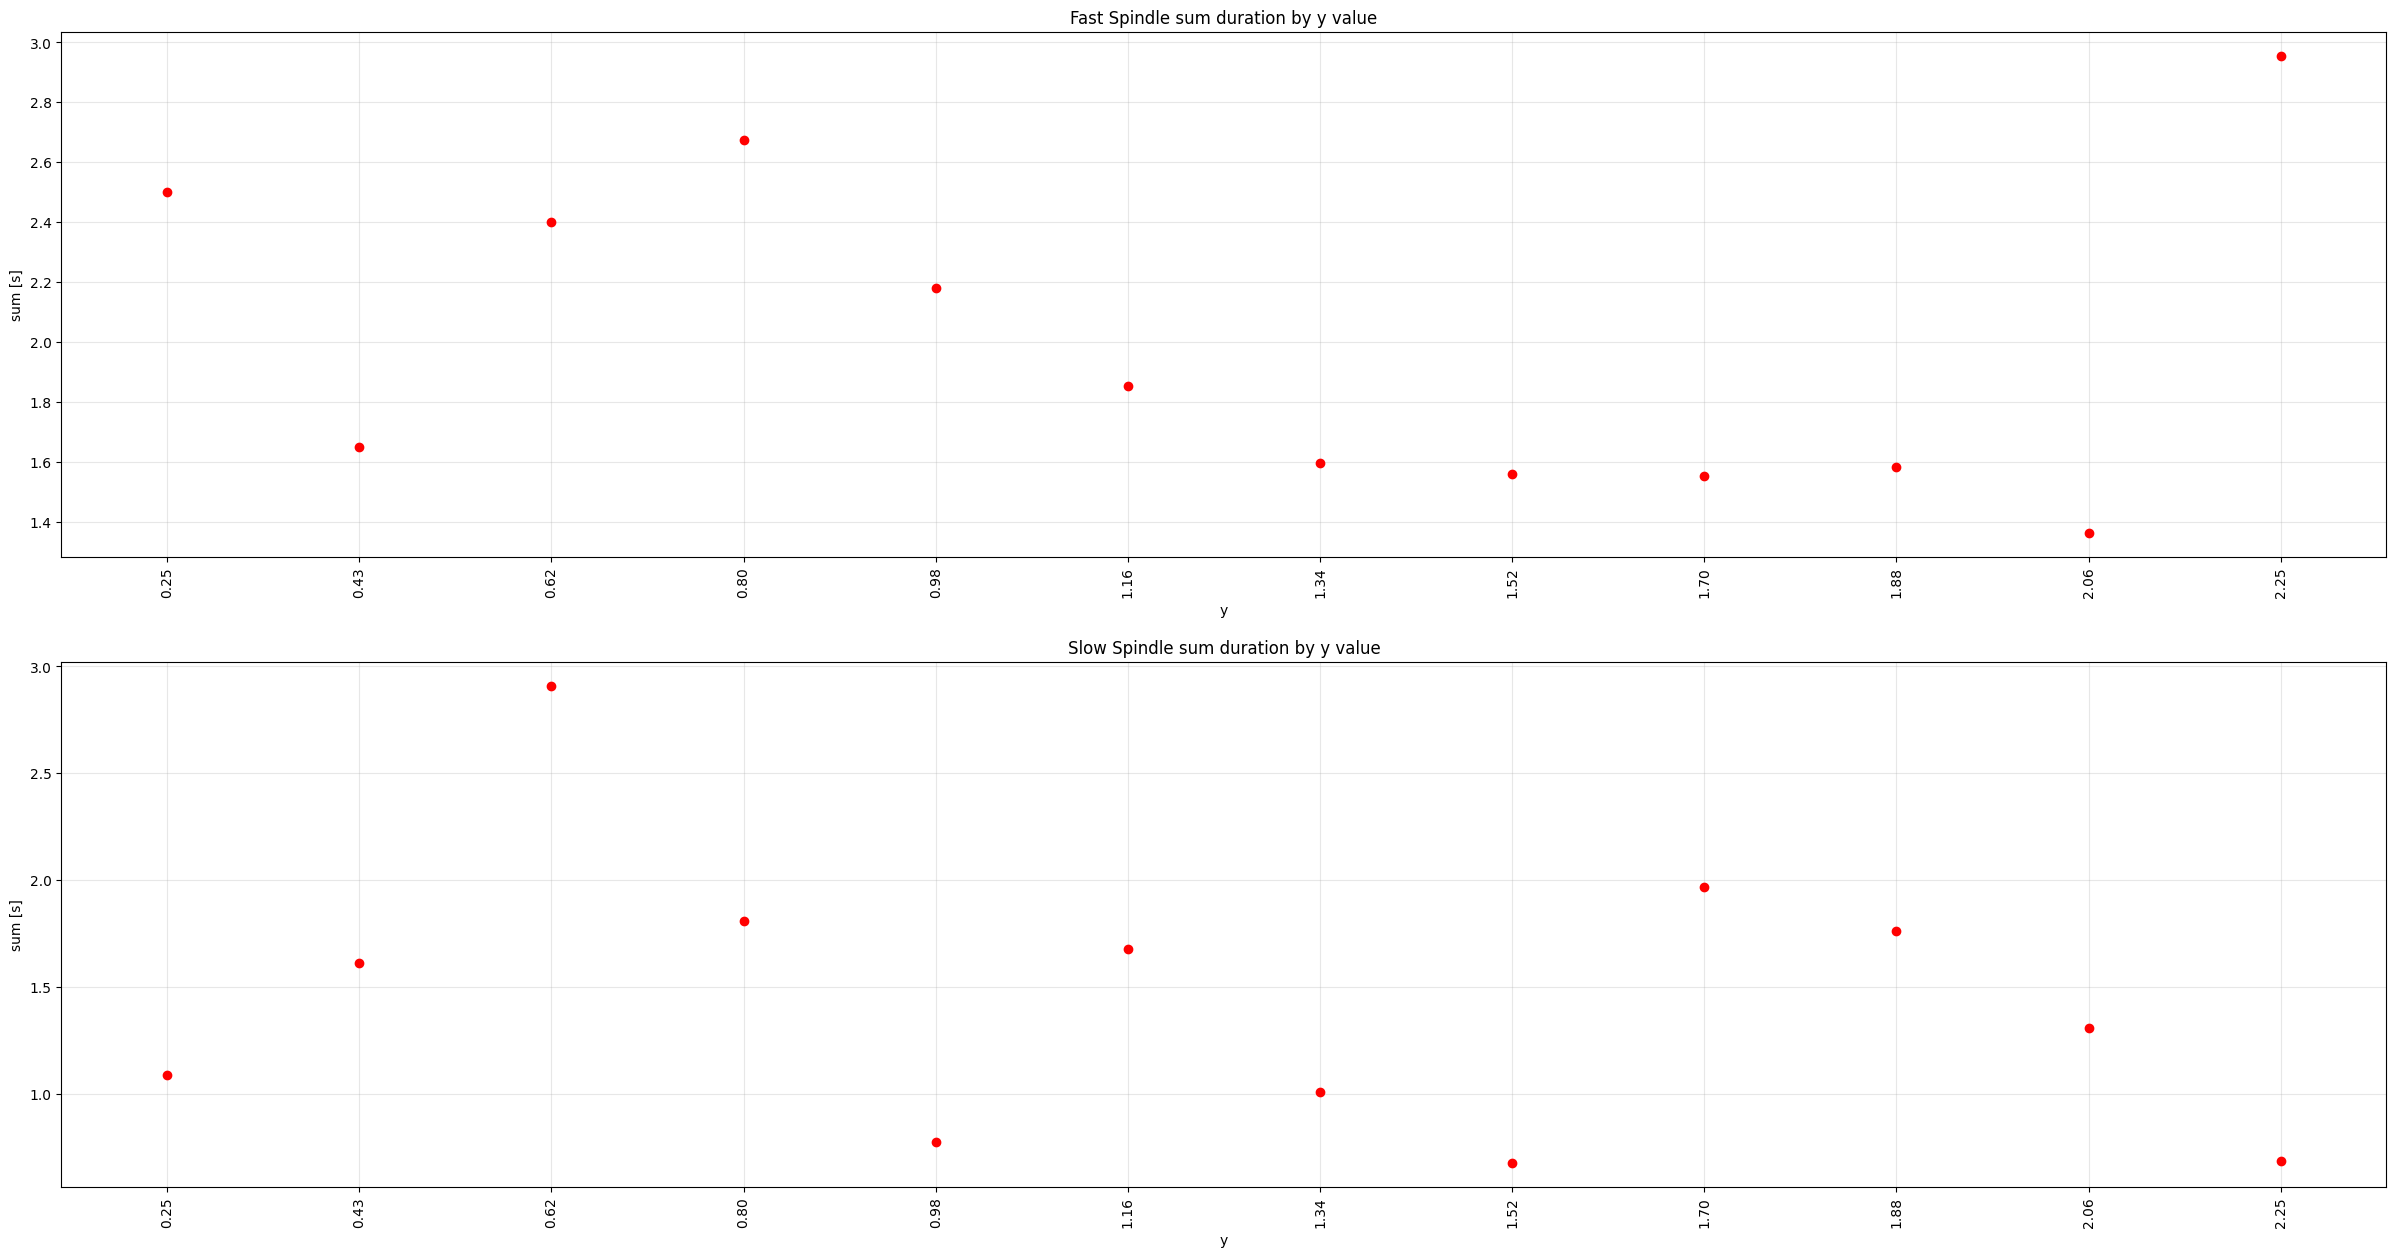

In [ ]:
# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))
#fig, ax = plt.subplots(1,1, figsize=(30, 7))
plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast.iterrows():
    plt.plot(row['y'], row['sum'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('sum [s]')
plt.title('Fast Spindle sum duration by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, [f'{y:.3f}' for y in y_values], rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow.iterrows():
    plt.plot(row['y'], row['sum'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('sum [s]')
plt.title('Slow Spindle sum duration by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, [f'{y:.3f}' for y in y_values], rotation=90)

'''
import os
# 创建保存目录（如果需要）
save_dir = 'D:/mynew/demo_all/data/figures'
# 保存图片
plt.savefig(os.path.join(save_dir, 'back_up_1.png'), 
            dpi=300, bbox_inches='tight')
'''
plt.show()




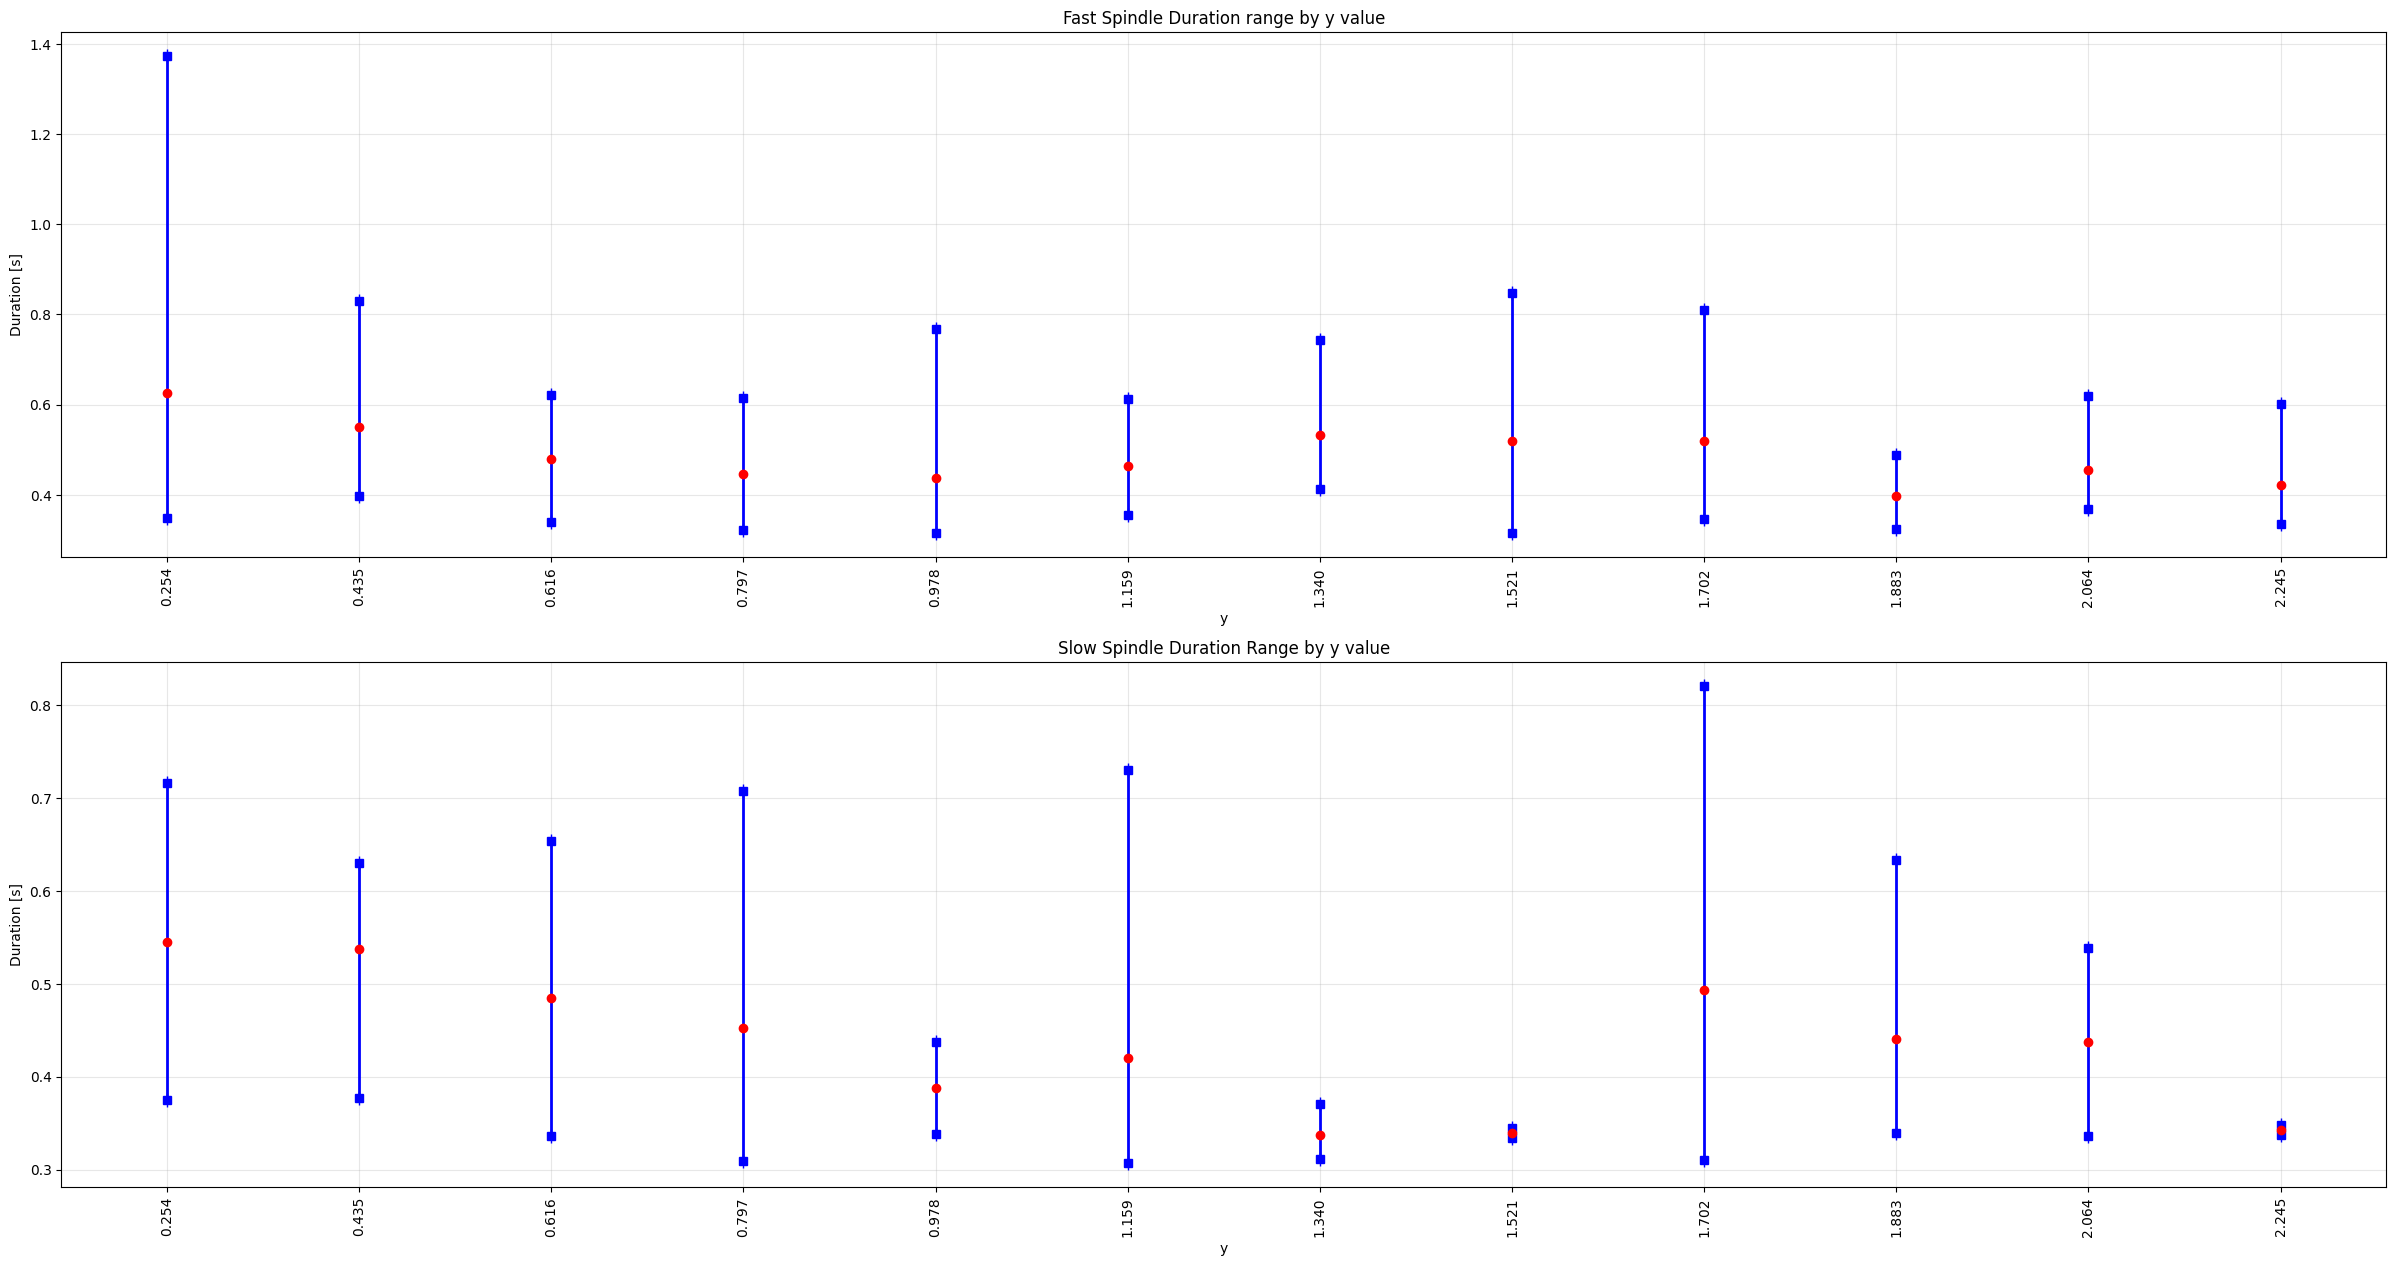

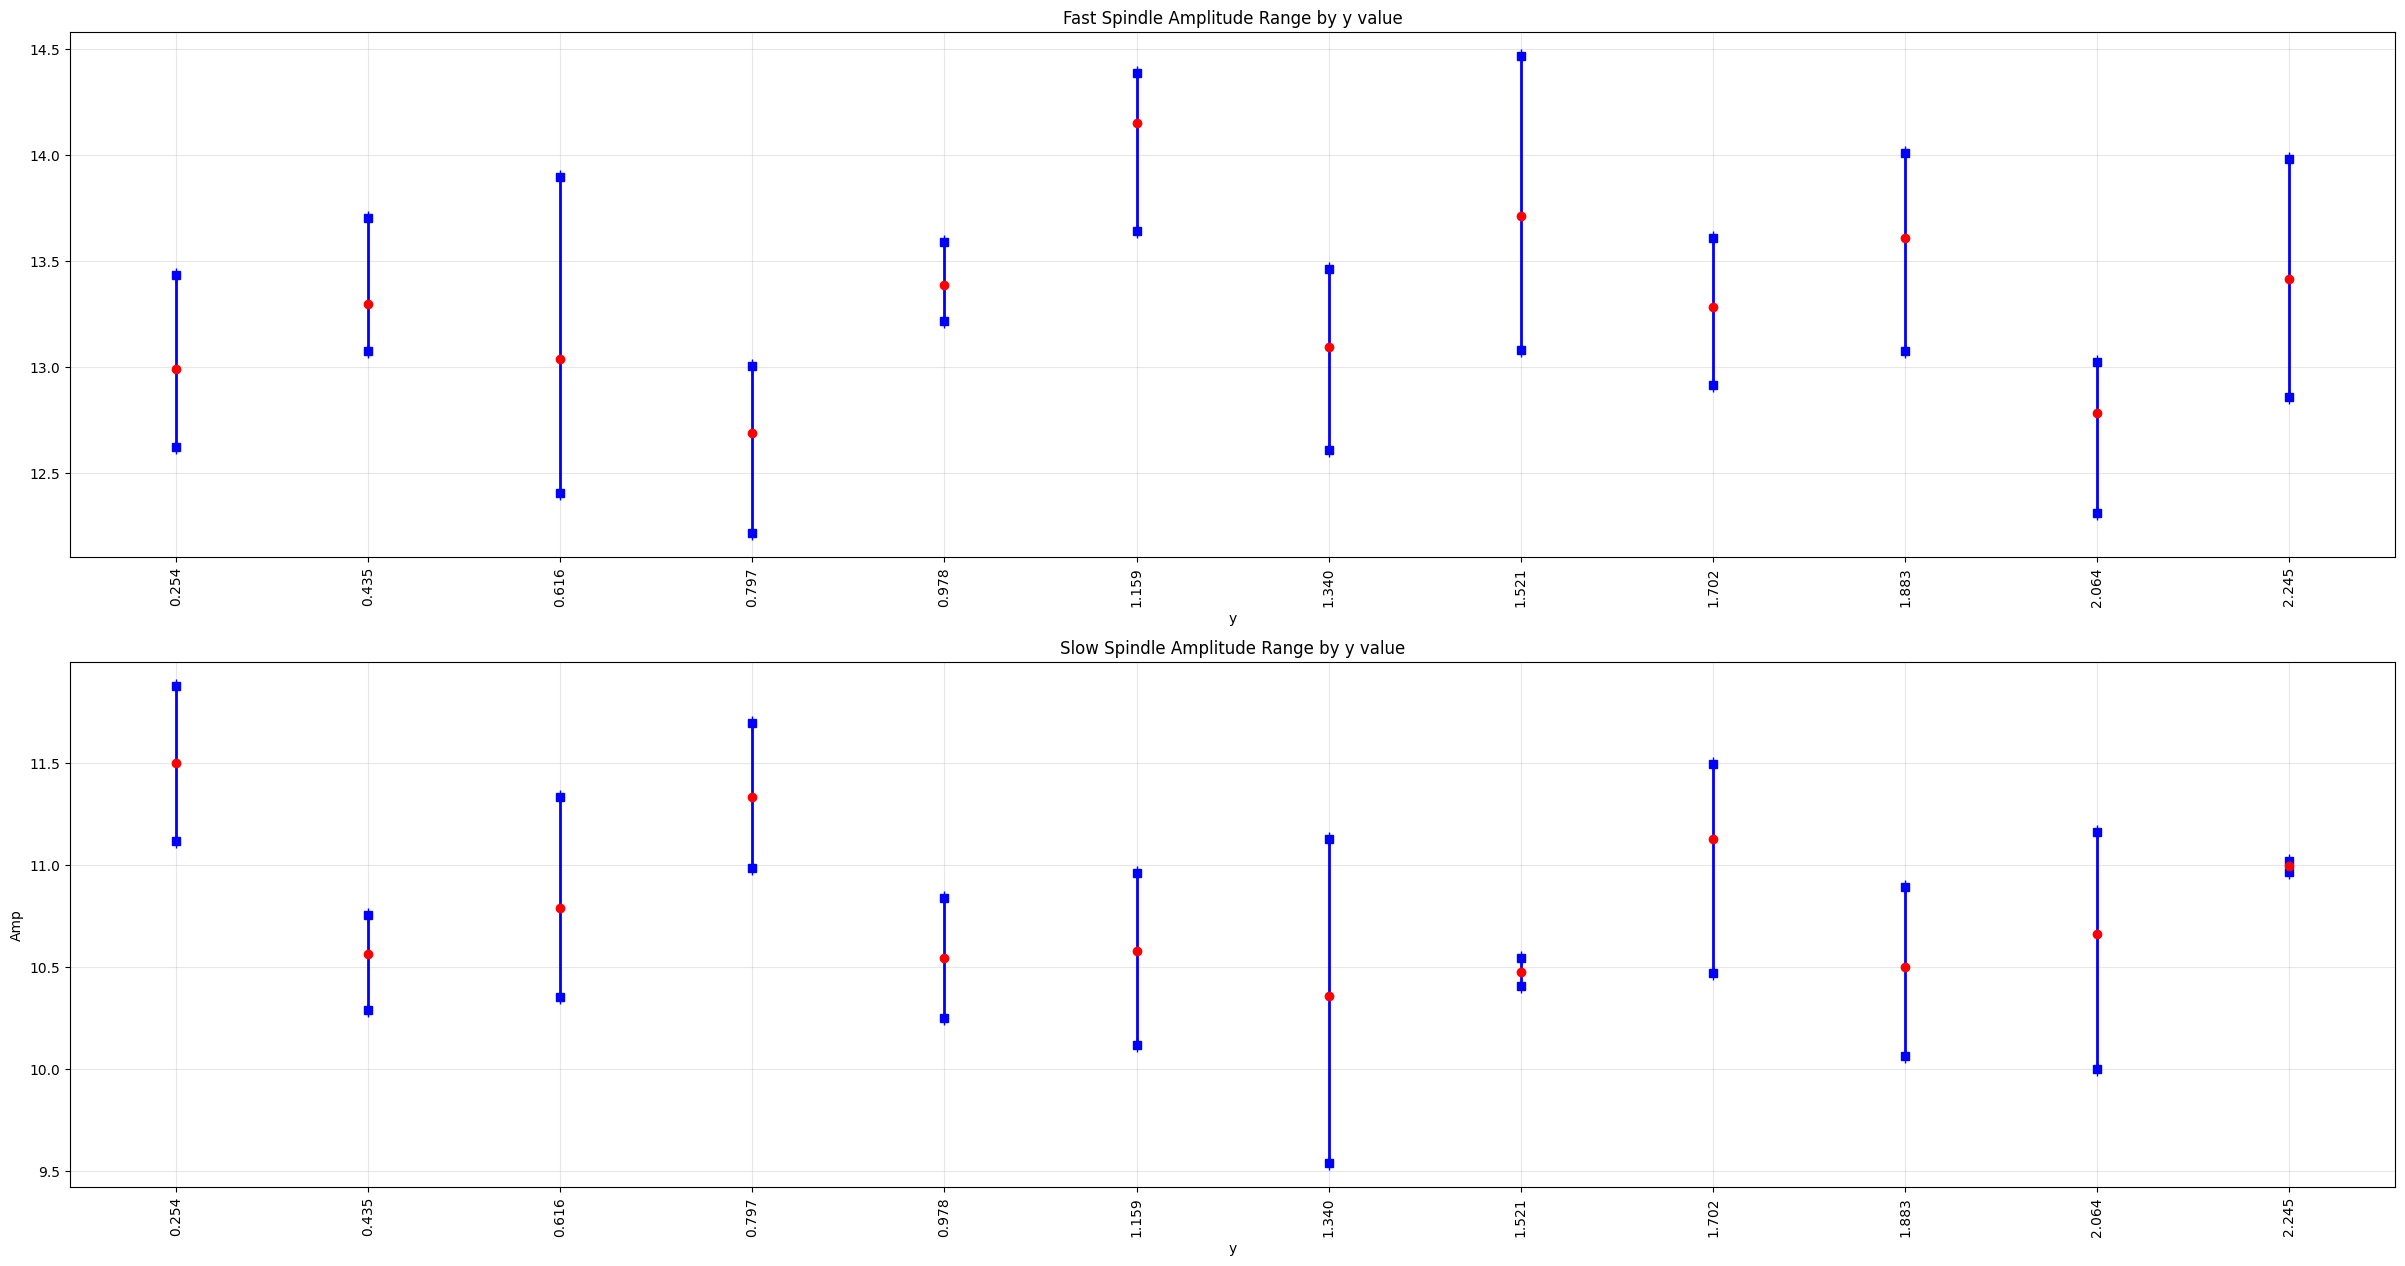

In [ ]:
# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Fast Spindle Duration range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Duration [s]')
plt.title('Slow Spindle Duration Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()


# for abspower and relpower
fig, ax = plt.subplots(2,1, figsize=(30, 15))

plt.subplot(2,1,1)
# 对每个y值画一条竖线
for idx, row in df_fast_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.title('Fast Spindle Amplitude Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.subplot(2,1,2)
# 对每个y值画一条竖线
for idx, row in df_slow_a.iterrows():
    plt.plot([row['y'], row['y']], [row['min'], row['max']], 
             'b-', linewidth=2, marker='|', markersize=10)
    
    # 可选：在两端添加点标记
    plt.plot(row['y'], row['min'], 'bs', markersize=6)
    plt.plot(row['y'], row['max'], 'bs', markersize=6)
    plt.plot(row['y'], row['mean'], 'ro', markersize=6)
    

plt.xlabel('y')
plt.ylabel('Amp')
plt.title('Slow Spindle Amplitude Range by y value')
plt.grid(True, alpha=0.3)
plt.xticks(y_values, rotation=90)

plt.show()


